In [ ]:
import sys, os
sys.path.insert(0, os.path.dirname(os.getcwd())) if os.path.basename(os.getcwd()) == "notebooks" else None

# Alinhamento facial — antes / depois

Compara imagens brutas do CelebA (`CelebA_data/celeba/img_align_celeba/img_align_celeba/`)
com o resultado do `FaceAligner` (`data/face_align.py`), lido do cache já gerado por
`train_attribute_classifier.py` em `./cache_aligned_celeba/`.

Lembrando: o `FaceAligner` **não** tenta reproduzir o crop original do CelebA — ele aplica
o template de 5 pontos do ArcFace, então o enquadramento/escala do rosto muda em relação
ao `img_align_celeba` original.

In [1]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

RAW_DIR = "./CelebA_data/celeba/img_align_celeba/img_align_celeba"
ALIGNED_DIR = "./cache_aligned_celeba"

assert os.path.isdir(RAW_DIR), f"Não encontrado: {RAW_DIR}"
assert os.path.isdir(ALIGNED_DIR), f"Não encontrado: {ALIGNED_DIR} (rode train_attribute_classifier.py primeiro)"

all_files = sorted(os.listdir(RAW_DIR))
print(f"{len(all_files)} imagens brutas, {len(os.listdir(ALIGNED_DIR))} alinhadas em cache.")

202599 imagens brutas, 202599 alinhadas em cache.


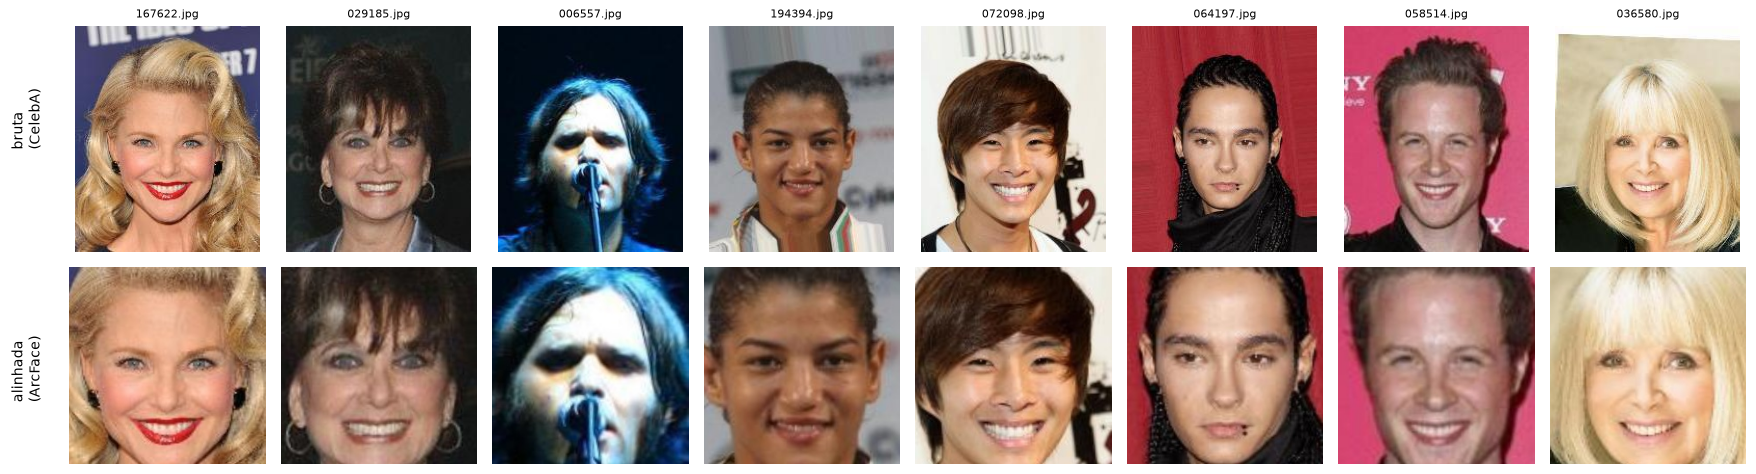

In [2]:
SEED = 42
N_SAMPLES = 8

rng = random.Random(SEED)
sample_files = rng.sample(all_files, N_SAMPLES)

fig, axes = plt.subplots(2, N_SAMPLES, figsize=(2.2 * N_SAMPLES, 5))

for col, fname in enumerate(sample_files):
    raw_img = Image.open(os.path.join(RAW_DIR, fname)).convert("RGB")
    aligned_img = Image.open(os.path.join(ALIGNED_DIR, fname)).convert("RGB")

    axes[0, col].imshow(raw_img)
    axes[0, col].set_title(fname, fontsize=8)
    axes[0, col].axis("off")

    axes[1, col].imshow(aligned_img)
    axes[1, col].axis("off")

fig.text(0.005, 0.75, "bruta\n(CelebA)", fontsize=10, ha="left", va="center", rotation=90)
fig.text(0.005, 0.25, "alinhada\n(ArcFace)", fontsize=10, ha="left", va="center", rotation=90)

plt.tight_layout(rect=[0.03, 0, 1, 1])
plt.show()

## Detecção de rosto: alinhado vs. fallback (center-crop)

O cache em `cache_aligned_celeba/` não guarda se cada imagem teve rosto detectado ou caiu
no fallback de center-crop (`FaceAligner._fallback_center_crop`). Para ver a diferença,
rodamos o aligner ao vivo em algumas imagens e mostramos a flag `found`.

In [3]:
import sys
sys.path.append(os.path.abspath("."))
from data.face_align import FaceAligner

aligner = FaceAligner(image_size=224)

live_samples = rng.sample(all_files, 8)
results = []
for fname in live_samples:
    raw_img = Image.open(os.path.join(RAW_DIR, fname)).convert("RGB")
    aligned_img, found = aligner.align_pil(raw_img)
    results.append((fname, raw_img, aligned_img, found))

n_found = sum(r[3] for r in results)
print(f"{n_found}/{len(results)} com rosto detectado nesta amostra.")

Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
model ignore: C:\Users\Lucas/.insightface\models\buffalo_l\1k3d68.onnx landmark_3d_68


Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
model ignore: C:\Users\Lucas/.insightface\models\buffalo_l\2d106det.onnx landmark_2d_106
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\Lucas/.insightface\models\buffalo_l\det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
model ignore: C:\Users\Lucas/.insightface\models\buffalo_l\genderage.onnx genderage


Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
model ignore: C:\Users\Lucas/.insightface\models\buffalo_l\w600k_r50.onnx recognition
set det-size: (640, 640)


C:\Users\Lucas\Projetos\diffusion-model\venv\Lib\site-packages\insightface\utils\face_align.py:23: FutureWarning: `estimate` is deprecated since version 0.26 and will be removed in version 2.2. Please use `SimilarityTransform.from_estimate` class constructor instead.
  tform.estimate(lmk, dst)


8/8 com rosto detectado nesta amostra.


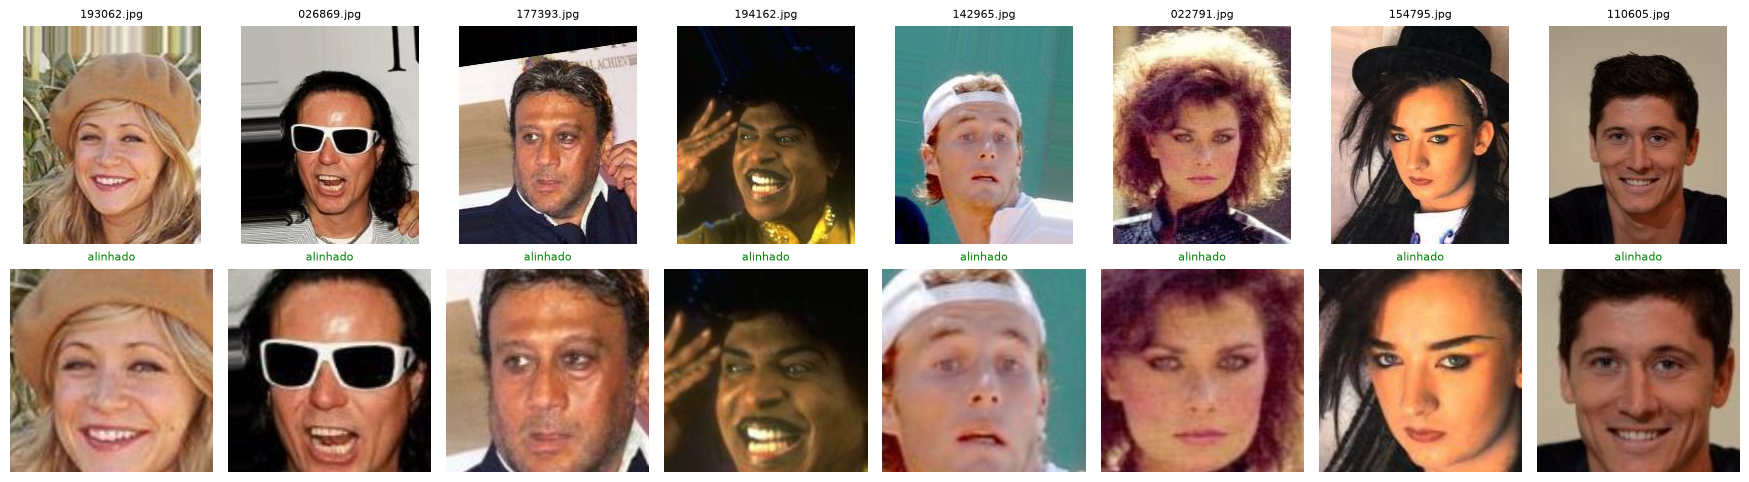

In [4]:
fig, axes = plt.subplots(2, len(results), figsize=(2.2 * len(results), 5))

for col, (fname, raw_img, aligned_img, found) in enumerate(results):
    axes[0, col].imshow(raw_img)
    axes[0, col].set_title(fname, fontsize=8)
    axes[0, col].axis("off")

    axes[1, col].imshow(aligned_img)
    tag = "alinhado" if found else "FALLBACK (sem rosto)"
    axes[1, col].set_title(tag, fontsize=8, color=("green" if found else "red"))
    axes[1, col].axis("off")

plt.tight_layout()
plt.show()